## Hyperparameter tuning

In [1]:
import wandb

In [2]:
import os
import gc
import sys
import time

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

import pyro
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import auc, roc_curve

In [ ]:
sys.path.append('../')
sys.path.append('../util')
sys.path.append('../models')

# LYNX imports
import IO, plot, utils, trajectory, metrics
import vgae, configs, dataset
from importlib import reload

### Utils

In [4]:
from scipy.spatial import cKDTree

def correct_mislabel_veins(adata, use_rep='ab_label', k=10):
    spatial_coords = adata.obsm["spatial"]
    labels = adata.obs[use_rep].values

    # Get indices for each label
    idx_label_1 = np.where(labels == 1)[0]
    idx_label_2 = np.where(labels == 2)[0]
    idx_label_3 = np.where(labels == 3)[0]

    # Build KD-trees for fast nearest-neighbor search
    tree_label_1 = cKDTree(spatial_coords[idx_label_1])
    tree_label_2 = cKDTree(spatial_coords[idx_label_2])

    # Find average distances from each label 3 cell to label 1 and label 2
    d1, _ = tree_label_1.query(spatial_coords[idx_label_3], k=k, workers=-1)
    d2, _ = tree_label_2.query(spatial_coords[idx_label_3], k=k, workers=-1)

    avg_d1 = d1.mean(axis=1)
    avg_d2 = d2.mean(axis=1)

    # Identify mislabeled 3s where avg distance to 1 is smaller than to 2
    mislabeled = avg_d1 < avg_d2
    labels[idx_label_3[mislabeled]] = 0  # Correct misclassified labels

    # Denoise
    labels = adata.obs[use_rep].values

    # Get indices for labels 0 & 3
    idx_label_0 = np.where(labels == 0)[0]
    idx_label_3 = np.where(labels == 3)[0]
    idx_0_3 = np.concatenate([idx_label_0, idx_label_3])  # Only process 0 & 3

    # Build KD-tree for spatial queries
    tree = cKDTree(spatial_coords)

    # Query nearest neighbors (excluding self)
    _, neighbors = tree.query(spatial_coords[idx_0_3], k=k+1, workers=-1)  # k+1 to exclude self

    # Count majority labels in neighbors
    for i, idx in enumerate(idx_0_3):
        neighbor_labels = labels[neighbors[i, 1:]]  # Exclude self
        majority_label = np.bincount(neighbor_labels).argmax()  # Most frequent label

        # Only update if the majority is different from the current label
        if majority_label in {0, 3} and majority_label != labels[idx]:
            labels[idx] = majority_label

    # Update AnnData object
    adata.obs[use_rep] = labels
    adata.obs[use_rep] = adata.obs[use_rep].astype('category')
    return None

def calculate_vein_axis(
    adata, use_rep='ab_label', 
    w1=.5, w2=.5, 
    vmin=0., vmax=1., k=10
):
    r"""Approx. annotation of PV -> CV axis from only antibody imaging"""
    # Extract spatial coordinates
    coords = adata.obsm['spatial']

    # Identify indices for each structure
    cv_indices = np.where(adata.obs[use_rep] == 0)[0]
    pp_indices = np.where(adata.obs[use_rep] == 2)[0]
    pv_indices = np.where(adata.obs[use_rep] == 3)[0]

    # Build KD-Trees for each structure
    cv_tree = cKDTree(coords[cv_indices])
    pp_tree = cKDTree(coords[pp_indices])
    pv_tree = cKDTree(coords[pv_indices])

    # Initialize array to hold PV-CV values
    axis_values = np.zeros(coords.shape[0])

    # Calculate mean distances to each structure
    for i, point in enumerate(coords):
        d_cv, _ = cv_tree.query(point, k=k)
        d_pp, _ = pp_tree.query(point, k=k)
        d_pv, _ = pv_tree.query(point, k=k)

        mu_cv = np.mean(d_cv)
        mu_pp = np.mean(d_pp)
        mu_pv = np.mean(d_pv)

        # Calculate H1(Medulla vs. Cortex) & H2 (Cortex vs. Capsule)
        H1 = (mu_pp - mu_pv) / (mu_pp + mu_pv)
        H2 = (mu_cv - mu_pp) / (mu_cv + mu_pp)

        # Combine H1 and H2 to get CMA value
        axis_values[i] = w1 * H1 + w2 * H2

    # Rescale to [vmin, vmax]
    axis_min, axis_max = np.min(axis_values), np.max(axis_values)
    axis_values = vmin + (axis_values - axis_min) * ((vmax-vmin) / (axis_max-axis_min))

    adata.obs['t'] = 1.0 - axis_values   # PV (0) --> CV (1)
    return None

### Load data

In [ ]:
# Load paired Xenium & DESI
xenium_path = '../../liver3d_bucket/Xenium example /processed'
desi_path = '../../liver3d_bucket/DESI/processed'
sample_id = 'NIH_F5'

adata_xenium = IO.load_xenium(os.path.join(xenium_path, sample_id))
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id+'.h5'))
adata_xenium, adata_desi = IO.filter_cells(adata_xenium, adata_desi, by='map')

In [ ]:
if 'cell_type' in adata_xenium.obs.keys():
    adata_xenium.obs['leiden'], categories = adata_xenium.obs.cell_type.factorize()
    categories = categories.values
else:
    adata_norm = adata_xenium.copy()
    sc.pp.normalize_total(adata_norm)
    sc.pp.log1p(adata_norm)

    sc.pp.pca(adata_norm)
    sc.pp.neighbors(adata_norm)
    sc.tl.leiden(adata_norm, random_state=42)
    adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
    del adata_norm   

In [7]:
# load antibody validation
ab_path = '../../data/antibody'
sample_id = 'NIH_F5'

adata_ab = IO.load_ab_stain(
    os.path.join(ab_path, sample_id+'.ome.tif'),
    adata_ref=adata_xenium
)

In [8]:
# Normalize to [0, 1] per channel
scaled_chans = np.zeros_like(adata_ab.X)
for i, chan in enumerate(adata_ab.X.T):
    chan = (chan-chan.min()) / (chan.max()-chan.min())
    scaled_chans[:, i] = chan

adata_ab.X = scaled_chans

ab_dict = {
    'Opal 690-GS': 'Central Vein',
    'Opal 780-CYP3A4': 'Peri-central',
    'Opal 570-ASS1': 'Peri-portal',
    'Opal 520-Col1': 'Portal Vein'
}
ab_labels = list(ab_dict.keys())

In [9]:
# Obtain 1-hot encoded argmax
argmax_expr = adata_ab.X.argmax(1)
adata_ab.obs['ab_label'] = argmax_expr
correct_mislabel_veins(adata_ab, k=50)
calculate_vein_axis(adata_ab, k=10)

In [10]:
y_gs = (adata_ab[:, ab_labels[0]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[0])).squeeze().astype(np.uint8)
y_cyp = (adata_ab[:, ab_labels[1]].X > metrics.get_antibody_threshold(adata_ab, ab_labels[1])).squeeze().astype(np.uint8)
y_ass = (adata_ab[:, ab_labels[2]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[2])).squeeze().astype(np.uint8)
y_col1 = (adata_ab[:, ab_labels[3]].X < metrics.get_antibody_threshold(adata_ab, ab_labels[3])).squeeze().astype(np.uint8)

y_antibodies = [y_gs, y_cyp, y_ass, y_col1]

## Hyperparam Sweep (latent) - 4/2/25 + 4/7/25

In [ ]:
wandb.login()

In [12]:
sweep_configuration = {
    "method": "grid",
    "name": "latent_dim",
    "metric": {"goal": "minimize", "name": "val_loss"},
    "parameters": {
        "latent_dim": {"values": [4, 6, 8, 10, 12]},
        "trial": {"values": [1, 2, 3]}
    },
}

In [ ]:
sweep_id = wandb.sweep(sweep=sweep_configuration, project="LYNX")

In [ ]:
# load dataset

# Dataset specs
n_subgraphs = 16
k = 20
r = 50
sigma = 20

graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_desi,
    n_subgraphs=n_subgraphs, 
    k=k,
    r=r,
    is_weighted=True,
    sigma=sigma,
    verbose=True
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

In [15]:
aps = {}

In [16]:
def main():
    run = wandb.init()

    adata_x = adata_xenium.copy()
    adata_d = adata_desi.copy()

    # Model parameters
    n_hidden = 32
    n_latent = wandb.config.latent_dim
    
    # Training parameters
    n_epochs = 400
    lr = 1e-2
    patience = 20
    
    # Training & Inference
    train_configs = configs.set_train_configs(
        n_epochs=n_epochs, lr=lr, patience=patience, 
        device=torch.device('cuda'),
        # scheduler step and gamma applies gamma every step
        # step_size=100, 
        gamma=0.995,
        verbose=True
    )
    
    model_configs = configs.set_model_configs(
        c_in=adata_xenium.shape[1],   # ref-dim 
        c_aux=adata_desi.shape[1],  # query-dim
        c_hidden=n_hidden, 
        c_latent=n_latent,
        act=nn.SiLU(),
        ref=graph_data.ref, 
        query=graph_data.query,
        num_clusters=graph_data.num_clusters,
        verbose=True,
        celltype_aware = True
    ) 

    model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
    model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True, log_wandb=True)

    # evaluate
    res = model.evaluate(
        adata_x, adata_d,
        graph_data=graph_data,
        device=torch.device('cpu')
    )

    # calculate t
    trajectory.compute_trajectory(
        adata_x, 
        use_rep='X_z',
        n_neighbors=100,
        root_marker='DPT'
    )
    trajectory.compute_trajectory(
        adata_d, 
        use_rep='X_z',
        n_neighbors=100,
        root_marker='Taurine '
    )

    utils.get_zonation_features(
        adata_x, adata_d, n_zones=5, option='piecewise', sample_id=sample_id
    )

    # antibody validation
    y_pred = adata_x.obs['t'].values
    fpr, tpr, _ = roc_curve(y_cyp, y_pred)
    roc_auc_cyp = auc(fpr, tpr)
    
    fpr, tpr, _ = roc_curve(y_ass, y_pred)
    roc_auc_ass = auc(fpr, tpr)

    ap = metrics.compute_ap(adata_x.obs['t'].values, y_antibodies)
    aps[(wandb.config.latent_dim, wandb.config.trial)] = ap

    run.summary["auc_cyp"] = roc_auc_cyp
    run.summary["auc_ass"] = roc_auc_ass
    # run.summary["ap"] = ap
    # run.summary.update()

    # save
    os.makedirs(f'../../results/latent_dim/dim{wandb.config.latent_dim}', exist_ok=True)

    del adata_x.uns['epg']
    del adata_d.uns['epg']
    adata_x.write_h5ad(f'../../results/latent_dim/dim{wandb.config.latent_dim}/adata_xenium_{wandb.config.trial}.h5')
    adata_d.write_h5ad(f'../../results/latent_dim/dim{wandb.config.latent_dim}/adata_desi_{wandb.config.trial}.h5')

    del model, adata_x, adata_d
    pyro.clear_param_store()
    torch.cuda.empty_cache()
    reload(vgae)

In [ ]:
wandb.agent(sweep_id, function=main)

In [30]:
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
aps_dict = aps
aps = np.array(list(aps.values()))
methods = [4, 6, 8, 10, 12]

[2025-04-07 15:17:01] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2025-04-07 15:17:01] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

4 vs. 6: t-test independent samples, P_val:7.873e-01 t=2.822e-01
10 vs. 12: t-test independent samples, P_val:8.156e-01 t=-2.437e-01


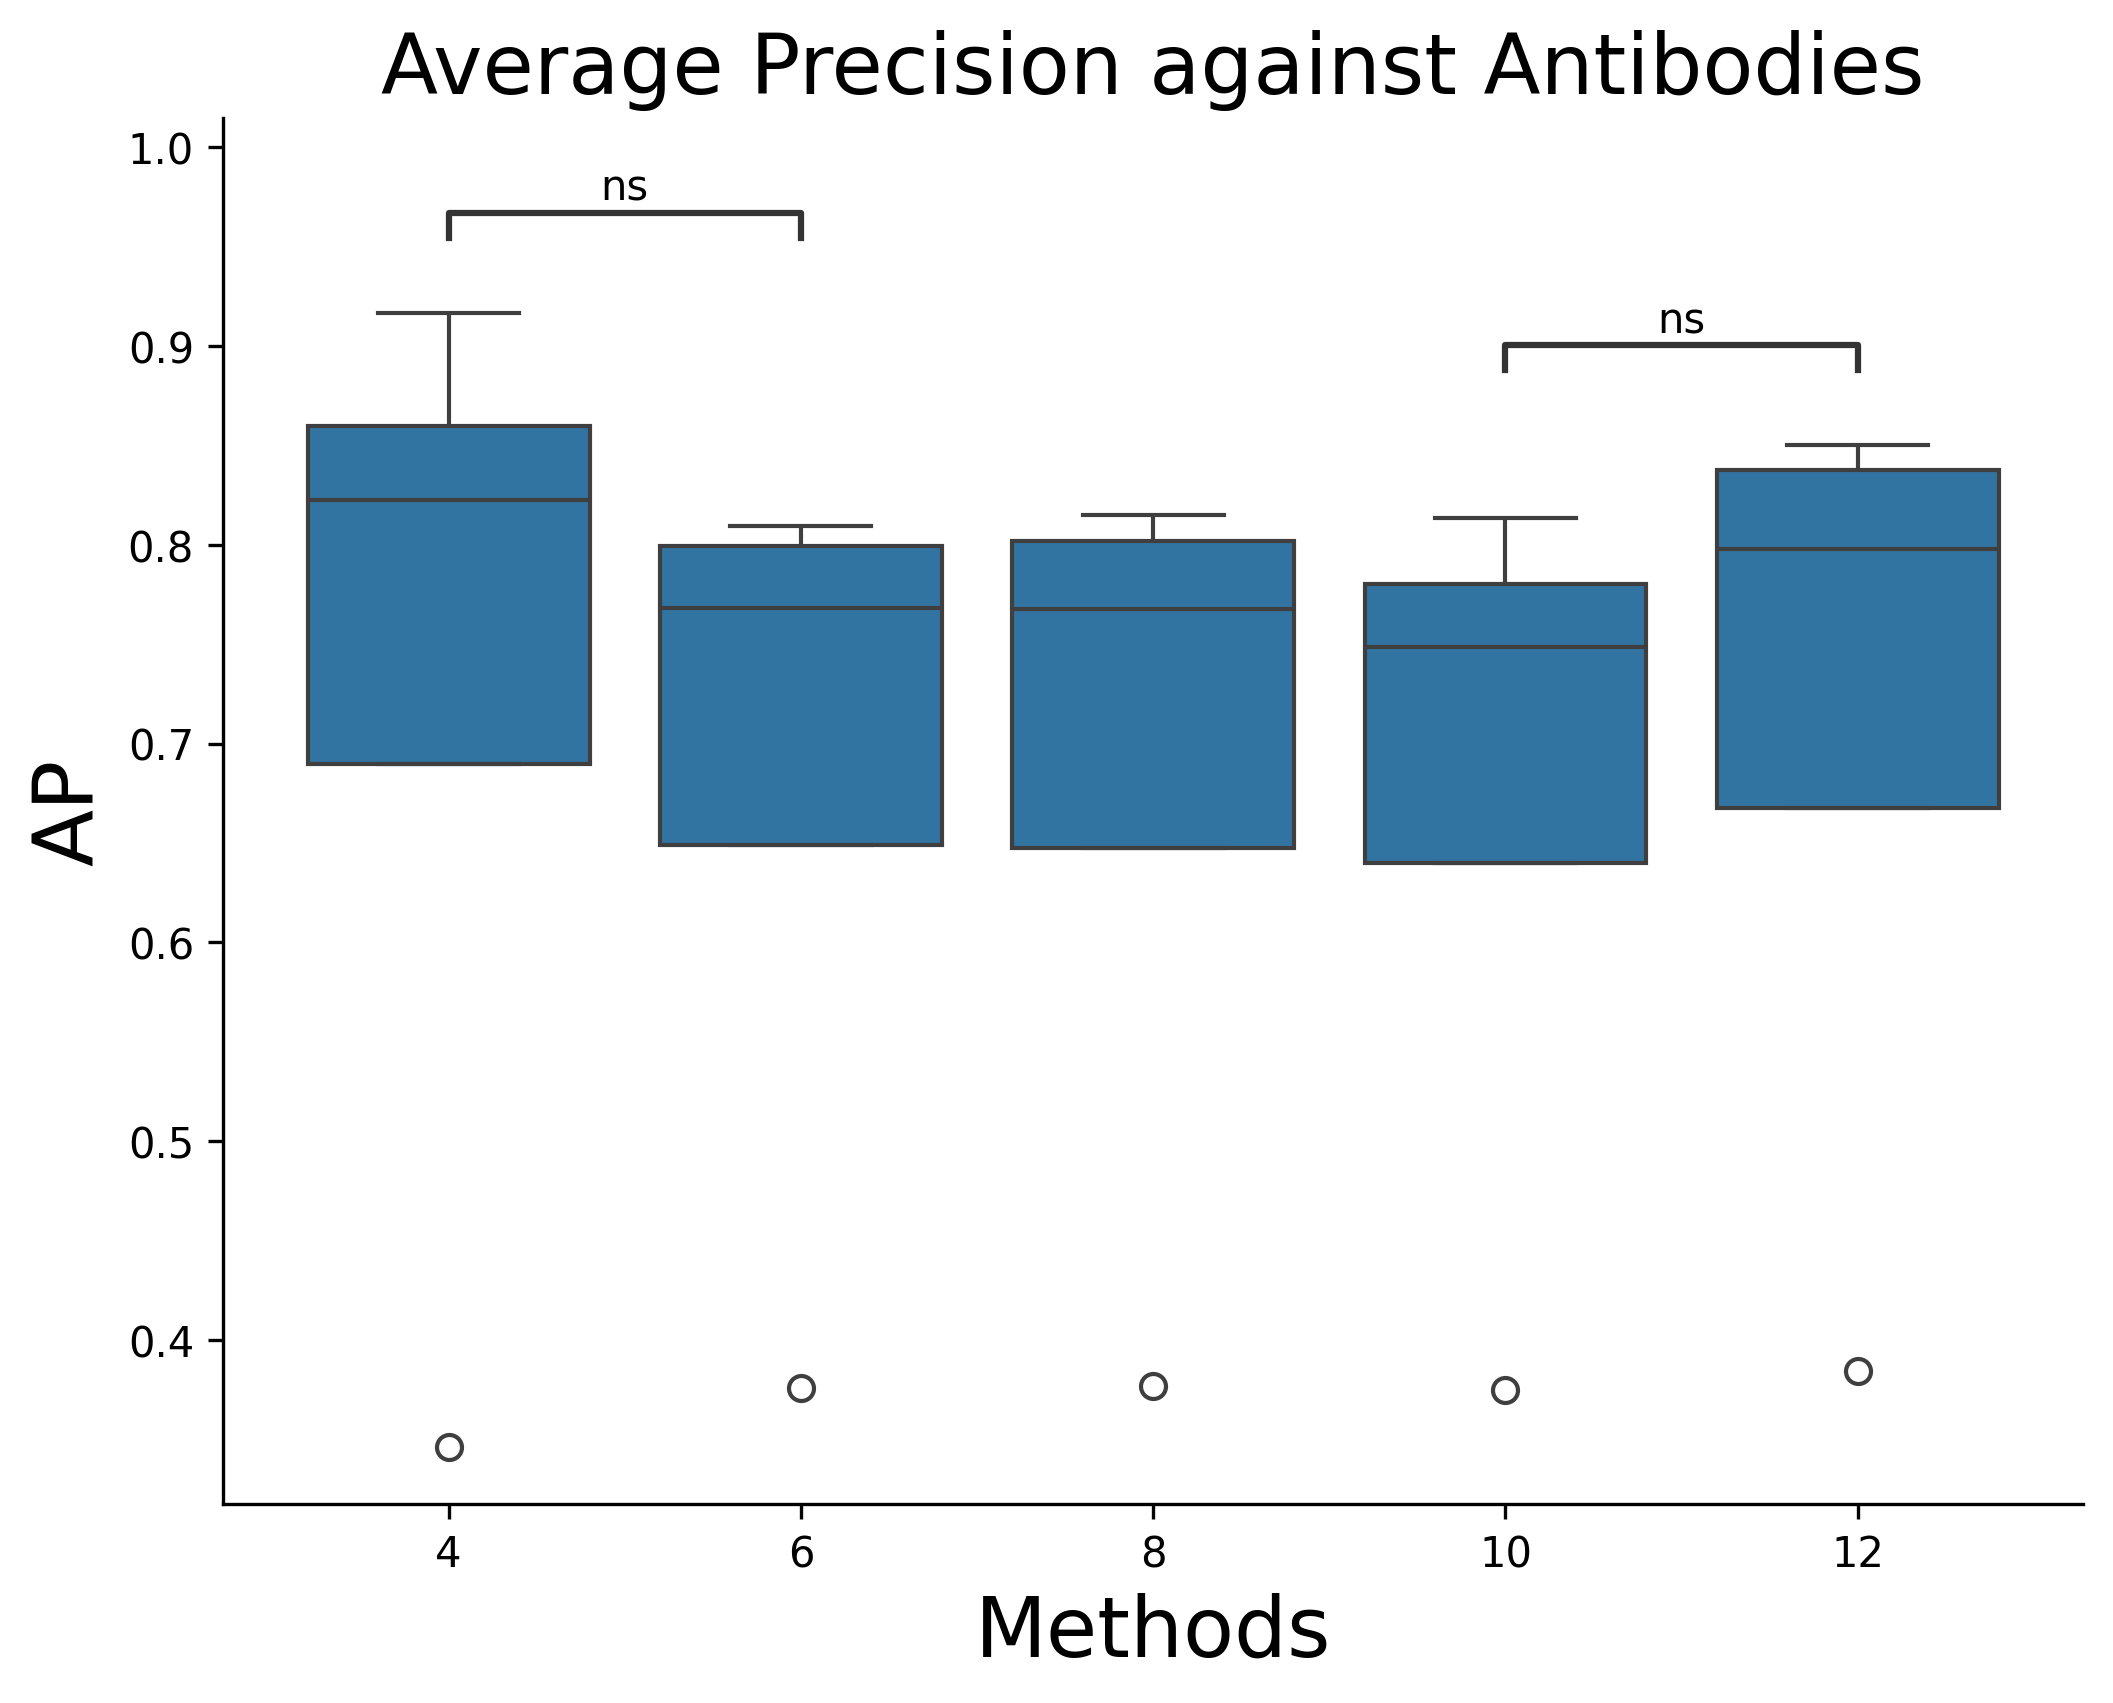

In [34]:
n_antibodies = aps[0].shape[0]
plot_df = pd.DataFrame({
    'AP': aps.flatten(),
    'Methods': np.repeat(methods, n_antibodies),
})

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
sns.boxplot(plot_df, x='Methods', y='AP', ax=ax)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Methods', fontsize=20)
ax.set_ylabel('AP', fontsize=20)
ax.set_title('Average Precision against Antibodies', fontsize=20)

pairs = [(4, 6), (10, 12)]
annotator = Annotator(ax, pairs, data=plot_df, x="Methods", y="AP")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show()

## Hyperparam Sweep 3/3/25

### Set wandb configs

In [ ]:
wandb.login()

In [ ]:
sweep_configuration = {
    "method": "grid",
    "name": "sweep",
    "metric": {"goal": "minimize", "name": "val_loss"},
    "parameters": {
        "graph_radius": {"values": [25, 50, 100]},
        "latent_dim": {"values": [4, 6, 8, 10, 12]},
        "lr": {"values": [1e-4, 1e-3, 1e-2]},
        "activation": {"values": ["SiLU", "ReLU", "LeakyReLU"]}
    },
}

In [ ]:
sweep_id = wandb.sweep(sweep=sweep_configuration, project="LYNX")

### Run Hyperparam Sweep

In [ ]:
def main():
    run = wandb.init()

    #### SET DATASET CONFIGS ####
    n_subgraphs = 16
    k = 100
    r = wandb.config.graph_radius
    sigma = 20
    
    graph_data = dataset.HeteroDataset(
        adatas_ref=adata_xenium, 
        adatas_query=adata_desi,
        n_subgraphs=n_subgraphs, 
        k=k,
        r=r,
        is_weighted=True,
        sigma=sigma,
        verbose=True
    )
    
    train_data, val_data = random_split(graph_data, [0.7, 0.3])
    train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

    #### SET MODEL CONFIGS ####

    # Model parameters
    n_hidden = 32
    n_latent = wandb.config.latent_dim
    act_dict = {"SiLU": nn.SiLU(), "ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU()}
    act = act_dict[wandb.config.activation]
    
    # Training parameters
    n_epochs = 500
    lr = wandb.config.lr
    patience = 20
    
    # Training & Inference
    train_configs = configs.set_train_configs(
        n_epochs=n_epochs, lr=lr, patience=patience, 
        device=torch.device('cuda'),
        anneal=False,
        verbose=True,
        #scheduler step and gamma applies gamma every step
        step_size=100, 
        gamma=0.1
    )
    
    model_configs = configs.set_model_configs(
        c_in=adata_xenium.shape[1],   # ref-dim 
        c_aux=adata_desi.shape[1],  # query-dim
        c_hidden=n_hidden, 
        c_latent=n_latent,
        act=act,
        ref=graph_data.ref, 
        query=graph_data.query,
        k_hop=1,
        num_heads=1,
        num_clusters=graph_data.num_clusters,
        verbose=True
    ) 

    # TRAIN
    model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
    model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True, log_wandb=True)

    del model, graph_data, train_data, val_data, train_dl, val_dl
    pyro.clear_param_store()
    torch.cuda.empty_cache()
    reload(vgae)

In [ ]:
wandb.agent(sweep_id, function=main)